In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("cv2 version:", cv2.__version__)

cv2 version: 4.12.0


###  Horizontal and vertical derivative filters

To analyze the edges in our synthetic image, we first convert `img_u8` from `uint8` \([0, 255]\) to normalized `float32` \([0, 1]\). We then apply two simple 1\-D derivative kernels:

- `Kx = [[-1, 0, 1]]` detects **horizontal changes** in intensity (vertical edges) and produces the response image `Gx`.
- `Ky = [[-1], [0], [1]]` detects **vertical changes** in intensity (horizontal edges) and produces the response image `Gy`.

Both filters are applied with `cv2.filter2D`, giving us two gradient images. Finally, we display `Gx` and `Gy` side by side using `matplotlib`:

- Left: `Gx` (response to horizontal derivative kernel).
- Right: `Gy` (response to vertical derivative kernel).

This lets us directly compare how each directional derivative responds to the shapes in the image.

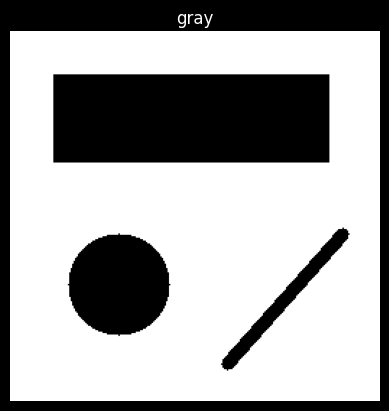

In [2]:
# 1) Create a simple test image
H, W = 256, 256
img_u8 = np.full((H, W), 255, np.uint8)  # white background
cv2.rectangle(img_u8, (30, 30), (220, 90), 0, thickness=-1)
cv2.circle(img_u8, (75, 175), 35, 0, thickness=-1)
cv2.line(img_u8, (150, 230), (230, 140), 0, thickness=7)
#show rectangle, circle, line
plt.figure()
plt.imshow(img_u8, cmap="gray")
plt.title("gray")
plt.axis("off")
plt.show()

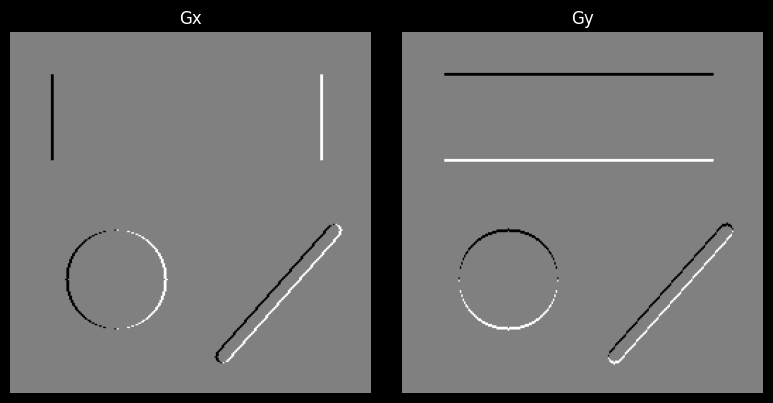

In [3]:
import numpy as np
import cv2

# img_u8: uint8 image in [0,255]
img = img_u8.astype(np.float32)

Kx = np.array([[-1, 0, 1]], np.float32)
Ky = np.array([[-1], [0], [1]], np.float32)

Gx = cv2.filter2D(img, cv2.CV_32F, Kx)
Gy = cv2.filter2D(img, cv2.CV_32F, Ky)


plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(Gx, cmap="gray")
plt.title("Gx")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Gy, cmap="gray")
plt.title("Gy")
plt.axis("off")

plt.tight_layout()
plt.show()


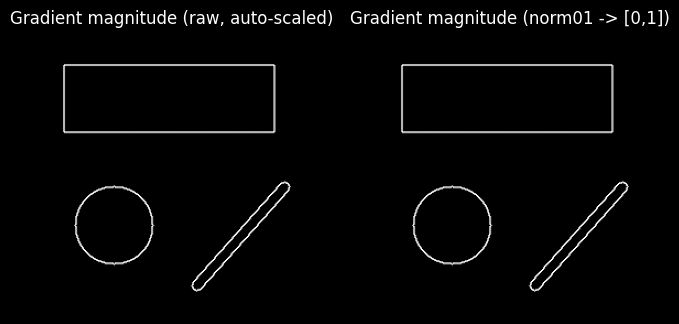

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mag = np.sqrt(Gx**2 + Gy**2)

# Function to normalize an array to [0, 1]
def norm01(x):
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# --- Display WITHOUT norm01 (raw values) ---
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mag, cmap="gray")   # matplotlib auto-scales by default
plt.title("Gradient magnitude (raw, auto-scaled)")
plt.axis("off")

# --- Display WITH norm01 (explicit rescale to [0,1]) ---
plt.subplot(1, 2, 2)
plt.imshow(norm01(mag), cmap="gray", vmin=0, vmax=1)
plt.title("Gradient magnitude (norm01 -> [0,1])")
plt.axis("off")
plt.show()



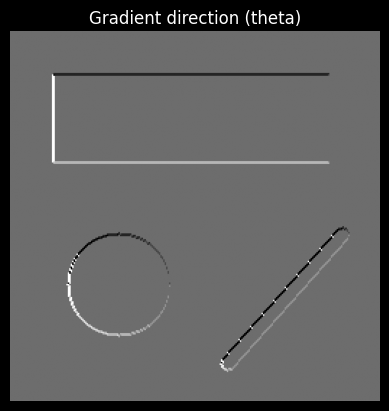

In [5]:
theta = np.arctan2(Gy, Gx)  # [-pi, pi]

# visualize theta as grayscale (wraps at -pi/pi)
theta_vis = (theta + np.pi) / (2*np.pi)  # -> [0,1]
plt.figure()
plt.imshow(theta, cmap="gray")
plt.title("Gradient direction (theta)")
plt.axis("off")
plt.show()

## Sobel = (finite-difference derivative) + (smoothing)

The Sobel operator is often described as a **smoothed finite-difference derivative**.

A common 1D “simple derivative” (central difference) stencil is:
\[
d = [-1;0;1]
\]
and a simple 1D smoothing (binomial / approx-Gaussian) stencil is:
\[
s = [1,2,1].
\]

The 2D Sobel kernels can be written as **separable outer products**:

$$
S_x = s\, d^\top,\qquad S_y = d\, s^\top.
$$

where

$$
s=\begin{bmatrix}1\\2\\1\end{bmatrix},\qquad
d=\begin{bmatrix}-1\\0\\1\end{bmatrix}.
$$

So:
- \(S_x\) = derivative in \(x\) (using \(d\)) **while smoothing in \(y\)** (using \(s\)),
- \(S_y\) = derivative in \(y\) **while smoothing in \(x\)**.

### Why Sobel behaves better than a raw derivative in noise
Taking a derivative amplifies high-frequency components (noise tends to be high-frequency).
Sobel partially counteracts this by adding **smoothing in the direction perpendicular to the derivative**, which reduces noise before it dominates the gradient estimate.

That is why Sobel typically gives cleaner edges than using only the simple derivative \([-1,0,1]\) in noisy images.


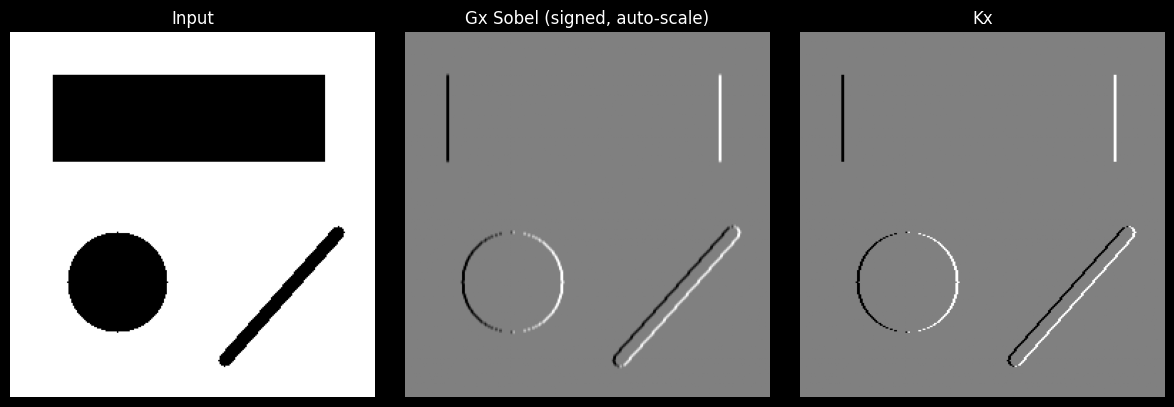

In [6]:
# Sobel-x kernel
Kx_sobel = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32)

Gx_sobel = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=Kx_sobel)

# Display (signed and absolute)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_u8, cmap="gray", vmin=0, vmax=255)
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Gx_sobel, cmap="gray")  # auto-scales
plt.title("Gx Sobel (signed, auto-scale)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(Gx, cmap="gray")  # edge strength in x-direction
plt.title("Kx")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# ----------------------------
# 1) Build a "meaningful" true image
#    (looks like a scanned paper with text + an ECG-like trace + a strong vertical edge)
# ----------------------------
H, W = 256, 256

# Background with a vertical illumination change (a real-world "scan" artifact)
img_true = np.full((H, W), 245, dtype=np.uint8)
img_true[:, :W//2] = 210  # left half slightly darker -> vertical edge at x=W//2

# Draw a paper border (meaningful structure)
cv2.rectangle(img_true, (12, 12), (W-12, H-12), color=235, thickness=2)



# Draw an ECG-like waveform (sine + sharp spikes)
x = np.arange(20, W-20)
baseline = 170
wave = (baseline + 12*np.sin(2*np.pi*(x-20)/60)).astype(np.int32)
img_wave = img_true.copy()
for i in range(len(x)-1):
    cv2.line(img_wave, (int(x[i]), int(wave[i])), (int(x[i+1]), int(wave[i+1])), color=30, thickness=2, lineType=cv2.LINE_AA)


img_true = img_wave

# ----------------------------
# 2) Create a corrupted observation: noise + a horizontal stain band that erases the edge locally
# ----------------------------
rng = np.random.default_rng(7)  # reproducible, local RNG (no global side effects)

img_noisy = img_true.astype(np.float32) + 12.0 * rng.standard_normal((H, W), dtype=np.float32)
img_noisy = np.clip(img_noisy, 0, 255)

img_corrupt = img_noisy.copy()
band = slice(H//2 - 3, H//2 + 3)  # ~6px tall stain band
# Wipe the right half inside the band so the left->right step edge disappears there
img_corrupt[band, W//2:] = np.mean(img_corrupt[band, :W//2])

# Convert to float32 in [0,1] for filtering
I = (img_corrupt / 255.0).astype(np.float32)

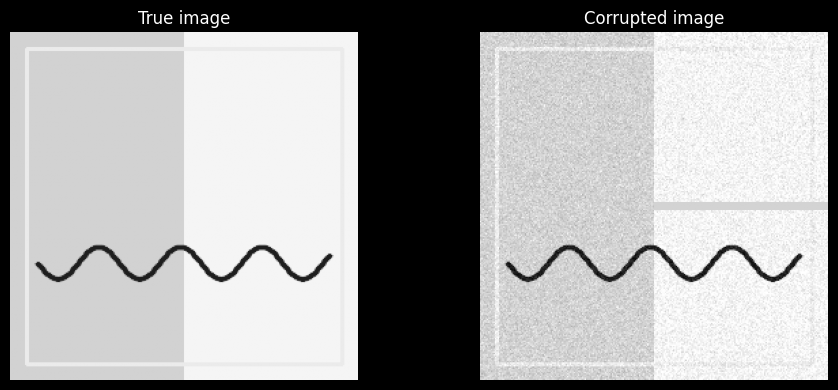

In [8]:
# Plot the two images: true and corrupted
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_true, cmap="gray", vmin=0, vmax=255)
plt.title("True image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_corrupt, cmap="gray", vmin=0, vmax=255)
plt.title("Corrupted image")
plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# ----------------------------
# 3) OpenCV convolution (filter2D) using only x-derivative
# ----------------------------
kx_simple = np.array([[0, 0, 0],
                      [-1, 0, 1],
                      [0, 0, 0]], dtype=np.float32) * 0.5  # central difference

kx_sobel = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32) / 8.0  # normalize so scale is comparable

dx_simple = cv2.filter2D(I, ddepth=cv2.CV_32F, kernel=kx_simple, borderType=cv2.BORDER_REPLICATE)
dx_sobel  = cv2.filter2D(I, ddepth=cv2.CV_32F, kernel=kx_sobel,  borderType=cv2.BORDER_REPLICATE)

mag_simple = np.abs(dx_simple)
mag_sobel  = np.abs(dx_sobel)

# Normalize magnitudes for display (0..1)
def norm01(a):
    mn, mx = float(a.min()), float(a.max())
    if mx - mn < 1e-12:
        return np.zeros_like(a, dtype=np.float32)
    return (a - mn) / (mx - mn)

disp_true    = norm01(img_true.astype(np.float32))
disp_corrupt = norm01(img_corrupt.astype(np.float32))
disp_simp    = norm01(mag_simple)
disp_sobel   = norm01(mag_sobel)


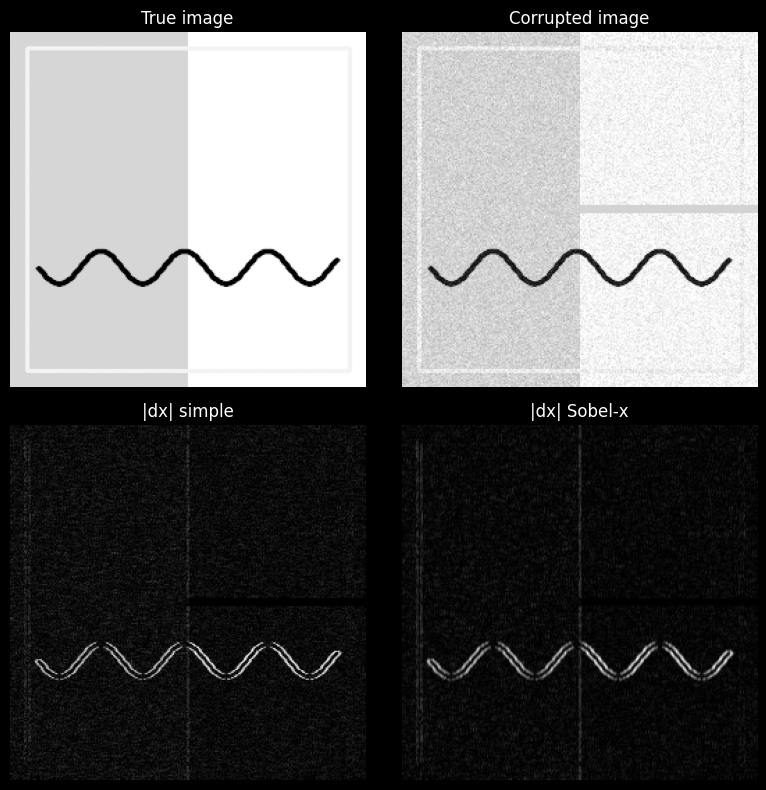

In [10]:


# ----------------------------
# 4\) Show images (2x2 grid)
# ----------------------------
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.imshow(disp_true, cmap="gray")
plt.title("True image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(disp_corrupt, cmap="gray")
plt.title("Corrupted image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(disp_simp, cmap="gray")
plt.title("|dx| simple")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(disp_sobel, cmap="gray")
plt.title("|dx| Sobel-x")
plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
# ----------------------------
# 5) Quantitative comparison: noise sensitivity in a flat area (top-left patch)
# ----------------------------
roi = (slice(10, 80), slice(10, 80))  # chosen where we did not draw text/wave
std_true= float(disp_true[roi].std())
std_simple = float(mag_simple[roi].std())
std_sobel  = float(mag_sobel[roi].std())

# Edge strength along the main vertical edge column (average outside stain band)
edge_x = W//2
rows_ok = np.r_[0:H//2-10, H//2+10:H]  # skip around the stain band
edge_strength_simple = float(mag_simple[rows_ok, edge_x].mean())
edge_strength_sobel  = float(mag_sobel[rows_ok, edge_x].mean())

print("Noise sensitivity (std of |dx| in a flat area):")
print(f"  true image:       {std_true:.6f}")
print(f"  simple derivative: {std_simple:.6f}")
print(f"  Sobel-x:           {std_sobel:.6f}")
print()
print("Edge strength (mean |dx| at the true vertical edge, excluding stain band):")
print(f"  simple derivative: {edge_strength_simple:.6f}")
print(f"  Sobel-x:           {edge_strength_sobel:.6f}")

Noise sensitivity (std of |dx| in a flat area):
  true image:       0.031982
  simple derivative: 0.021239
  Sobel-x:           0.014707

Edge strength (mean |dx| at the true vertical edge, excluding stain band):
  simple derivative: 0.067396
  Sobel-x:           0.066425


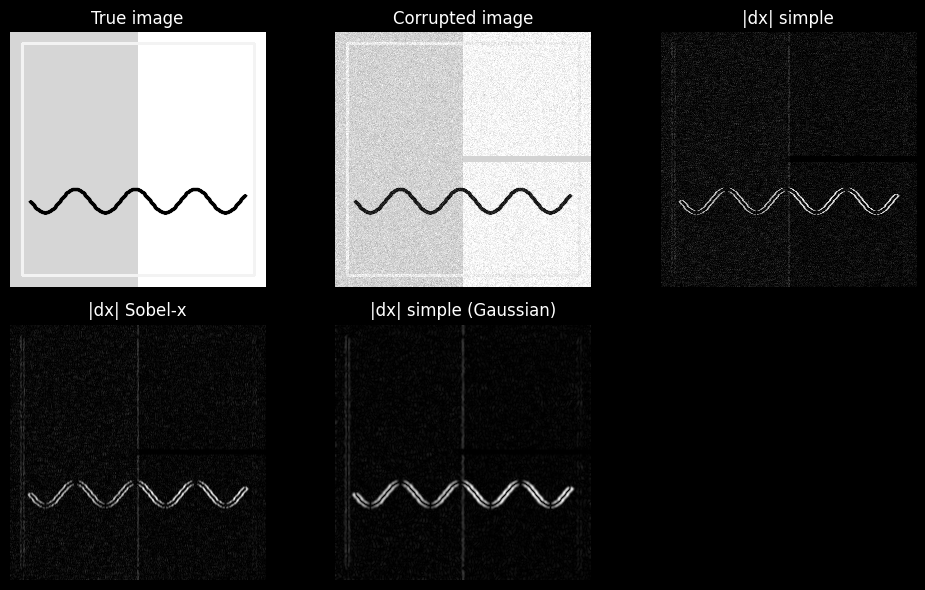

In [12]:
# Convollute dx_simple with a small Gaussian to reduce noise
dx_simple_smooth = cv2.GaussianBlur(dx_simple, ksize=(5,5), sigmaX=1.0, borderType=cv2.BORDER_REPLICATE)
mag_simple_smooth = np.abs(dx_simple_smooth)
disp_simp_smooth = norm01(mag_simple_smooth)
# Display smoothed result besides clean and noisy ones and simple derivative and Sobel
# Normalize magnitudes (reuse norm01)
disp_true        = norm01(img_true.astype(np.float32))
disp_corrupt     = norm01(img_corrupt.astype(np.float32))
disp_simp        = norm01(mag_simple)
disp_sobel       = norm01(mag_sobel)
disp_simp_smooth = norm01(mag_simple_smooth)

# Display: true, corrupted, |dx| simple, |dx| Sobel, |dx| simple (Gaussian-smoothed)
plt.figure(figsize=(10, 6))

plt.subplot(2, 3, 1)
plt.imshow(disp_true, cmap="gray", vmin=0, vmax=1)
plt.title("True image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(disp_corrupt, cmap="gray", vmin=0, vmax=1)
plt.title("Corrupted image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(disp_simp, cmap="gray", vmin=0, vmax=1)
plt.title("|dx| simple")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(disp_sobel, cmap="gray", vmin=0, vmax=1)
plt.title("|dx| Sobel-x")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(disp_simp_smooth, cmap="gray", vmin=0, vmax=1)
plt.title("|dx| simple (Gaussian)")
plt.axis("off")

plt.tight_layout()
plt.show()




In [13]:
# Quantitative comparison after Gaussian smoothing
std_simple_smooth = float(mag_simple_smooth[roi].std())
edge_strength_simple_smooth = float(mag_simple_smooth[rows_ok, edge_x].mean())
print("After Gaussian smoothing of |dx| simple:")
print("Noise sensitivity (std of |dx| in a flat area):")
print(f"  simple derivative (Gaussian): {std_simple_smooth:.6f}")
print(f"  noise on simple derivative reduced from {std_simple:.6f} to {std_simple_smooth:.6f}")
print(f"  noise on Sobel-x remains at {std_sobel:.6f}")

After Gaussian smoothing of |dx| simple:
Noise sensitivity (std of |dx| in a flat area):
  simple derivative (Gaussian): 0.007503
  noise on simple derivative reduced from 0.021239 to 0.007503
  noise on Sobel-x remains at 0.014707


## Steerable filters (what is exact vs approximate)

### What “steerable” means (Freeman & Adelson)
A filter family $h_{\theta}$ is **steerable** if each rotated filter can be synthesized from a **fixed set of basis filters**:

$$
h_{\theta} \;=\; \sum_{k=1}^{M} a_k(\theta)\, h_{\theta_k},
$$

where the basis orientations $\{\theta_k\}$ are fixed, and only the weights $a_k(\theta)$ depend on $\theta$.

This is useful because rotating a discrete filter for many angles is expensive and introduces interpolation artifacts. With steerability, you compute a few basis responses once, then combine them using cheap scalar weights.

---

### “Steering the response” (directional derivative idea)
If you have two basis derivative filters that approximate $\partial_x$ and $\partial_y$, and their responses are

$$
G_x \;=\; I * h_x,\qquad G_y \;=\; I * h_y,
$$

then a **steered directional response** can be formed as

$$
R_{\theta} \;:=\; \cos\theta\,G_x \;+\; \sin\theta\,G_y.
$$

A related kernel is

$$
h_{\theta} \;:=\; \cos\theta\,h_x \;+\; \sin\theta\,h_y.
$$

**Important distinction:**

- The identity

$$
I * h_{\theta} \;=\; \cos\theta\,(I*h_x) \;+\; \sin\theta\,(I*h_y)
$$

is always true, because convolution is linear.

- But this does **not** automatically mean that $h_{\theta}$ is a *geometric rotation* of some single “mother filter” $h$.

---

### Why Gaussian derivatives are special (exact steerability)
For **Gaussian derivative filters**, steerability is exact in the Freeman–Adelson sense because the Gaussian is rotationally symmetric (isotropic) and its derivatives have controlled angular structure.

For example, for the first derivative of a Gaussian:

$$
\partial_{\theta} G_{\sigma}
\;=\;
\cos\theta\,\partial_x G_{\sigma} \;+\; \sin\theta\,\partial_y G_{\sigma}.
$$

This corresponds to steering a rotated directional derivative operator without having to rotate any discrete kernel.

---

### What about Sobel (and other discrete stencils)?
For Sobel or simple finite-difference stencils, using

$$
R_{\theta} \;=\; \cos\theta\,G_x \;+\; \sin\theta\,G_y
$$

is a useful **approximation** to a directional derivative response, but in general it is **not equal** to “a Sobel kernel rotated by $\theta$” on the discrete pixel grid.

So:

- **Gaussian derivatives:** steering corresponds closely to rotating the underlying continuous operator (exact theory).
- **Sobel / finite differences:** steering the responses is valid and often useful, but the equivalence to a rotated filter is only approximate.

---

### Practical takeaway
Instead of rotating a filter for many angles, compute responses to a **fixed basis** (e.g., $\partial_x G_{\sigma}$ and $\partial_y G_{\sigma}$, or a small set of oriented Gaussian-derivative bases), then synthesize responses at any angle using angle-dependent weights.


In [14]:
# -------------------------
# Build a test image: diagonal step edge (45°) + noise
# -------------------------
H, W = 256, 256
yy, xx = np.mgrid[0:H, 0:W]

I_true = np.where(xx + yy >= W, 0.85, 0.15).astype(np.float32)

rng = np.random.default_rng(3)
I_noisy = np.clip(I_true + 0.00 * rng.standard_normal((H, W), dtype=np.float32), 0.0, 1.0).astype(np.float32)

# -------------------------
# Sobel derivatives (x and y only)
# -------------------------
Gx = cv2.Sobel(I_noisy, cv2.CV_32F, dx=1, dy=0, ksize=3, borderType=cv2.BORDER_REPLICATE)
Gy = cv2.Sobel(I_noisy, cv2.CV_32F, dx=0, dy=1, ksize=3, borderType=cv2.BORDER_REPLICATE)

mag_fx = np.abs(Gx)
mag_fy = np.abs(Gy)

# Steered directional derivative at the "correct" angle: 45°
theta = np.deg2rad(-30.0)
Rtheta = np.cos(theta) * Gx + np.sin(theta) * Gy
mag_th = np.abs(Rtheta)

# Choose a threshold so fx-only and fy-only fail, but theta succeeds
max_comp = max(float(mag_fx.max()), float(mag_fy.max()))
max_th = float(mag_th.max())
t = 1.05 * max_comp  # just above component max (and typically below steered max)

edge_fx = (mag_fx > t).astype(np.uint8)
edge_fy = (mag_fy > t).astype(np.uint8)
edge_th = (mag_th > t).astype(np.uint8)



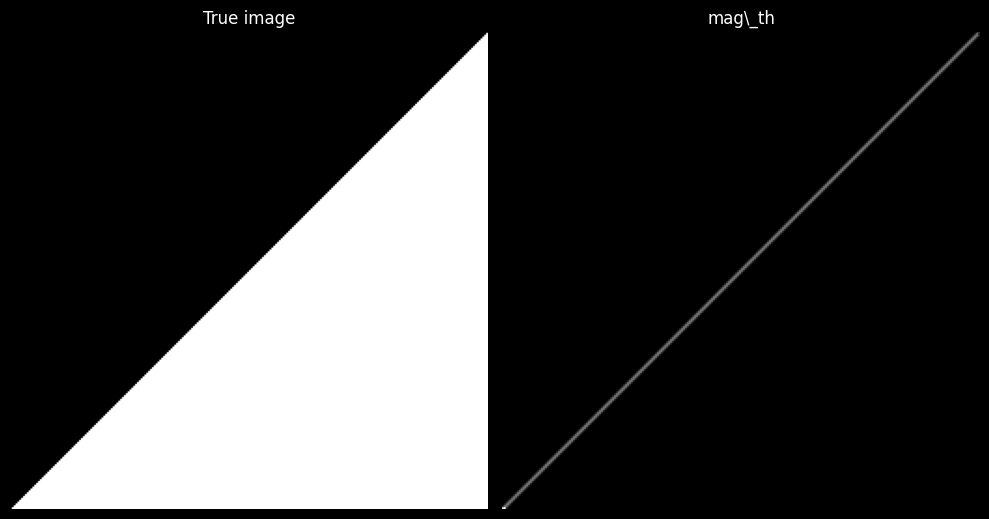

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
cmap_img = 'gray'

# True image
axes[0].imshow(I_true, cmap=cmap_img)
axes[0].set_title('True image')
axes[0].axis('off')

# mag\_th
axes[1].imshow(mag_th, cmap=cmap_img)
axes[1].set_title('mag\_th')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [16]:
print("max(|fx|), max(|fy|), max(|fθ|):", float(mag_fx.max()), float(mag_fy.max()), float(mag_th.max()))
print("threshold t:", t)
print("edge pixel counts (fx, fy, theta):", int(edge_fx.sum()), int(edge_fy.sum()), int(edge_th.sum()))


max(|fx|), max(|fy|), max(|fθ|): 2.8000001907348633 2.8000001907348633 1.7248712480939496
threshold t: 2.9400002002716064
edge pixel counts (fx, fy, theta): 0 0 0


In [17]:
# -------------------------
# Derivative-of-Gaussian derivatives (x and y)
# -------------------------
def gaussian_1d_and_derivative(sigma: float, radius: int | None = None):
    if radius is None:
        radius = int(np.ceil(3 * sigma))  # ~99.7% mass
    x = np.arange(-radius, radius + 1, dtype=np.float32)

    g = np.exp(-(x * x) / (2 * sigma * sigma))
    g /= g.sum()  # sum to 1

    gp = -(x / (sigma * sigma)) * g  # derivative of Gaussian
    gp -= gp.mean()                  # enforce ~zero-sum numerically

    # Optional: normalize derivative magnitude for comparability across sigma
    gp /= (np.sum(np.abs(gp)) + 1e-12)

    return g.astype(np.float32), gp.astype(np.float32)

sigma = 1.0
g, gp = gaussian_1d_and_derivative(sigma)

# Gx = d/dx (Gaussian * I)  == (g'(x) * g(y)) * I
Gx = cv2.sepFilter2D(I_noisy, cv2.CV_32F, gp, g, borderType=cv2.BORDER_REPLICATE)

# Gy = d/dy (Gaussian * I)  == (g(x) * g'(y)) * I
Gy = cv2.sepFilter2D(I_noisy, cv2.CV_32F, g, gp, borderType=cv2.BORDER_REPLICATE)

mag_fx = np.abs(Gx)
mag_fy = np.abs(Gy)
theta = np.deg2rad(-30)  # for xx + yy = const edge
Rtheta = np.cos(theta) * Gx + np.sin(theta) * Gy
mag_th = np.abs(Rtheta)


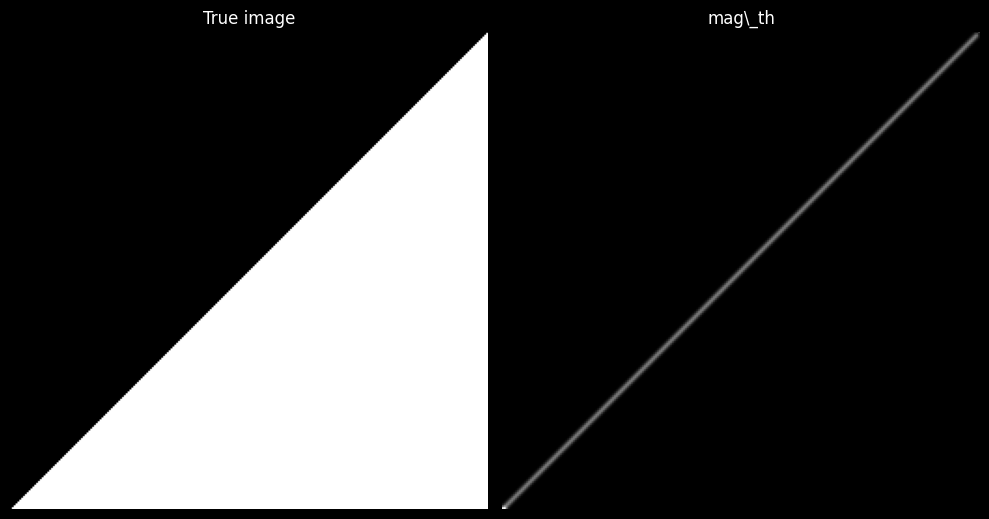

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
cmap_img = 'gray'

# True image
axes[0].imshow(I_true, cmap=cmap_img)
axes[0].set_title('True image')
axes[0].axis('off')

# mag\_th
axes[1].imshow(mag_th, cmap=cmap_img)
axes[1].set_title('mag\_th')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [19]:
print("max(|fx|), max(|fy|), max(|fθ|):", float(mag_fx.max()), float(mag_fy.max()), float(mag_th.max()))
print("threshold t:", t)
print("edge pixel counts (fx, fy, theta):", int(edge_fx.sum()), int(edge_fy.sum()), int(edge_th.sum()))


max(|fx|), max(|fy|), max(|fθ|): 0.3359140455722809 0.3359140455722809 0.20658889610597314
threshold t: 2.9400002002716064
edge pixel counts (fx, fy, theta): 0 0 0
